NameError: name 'tools' is not defined

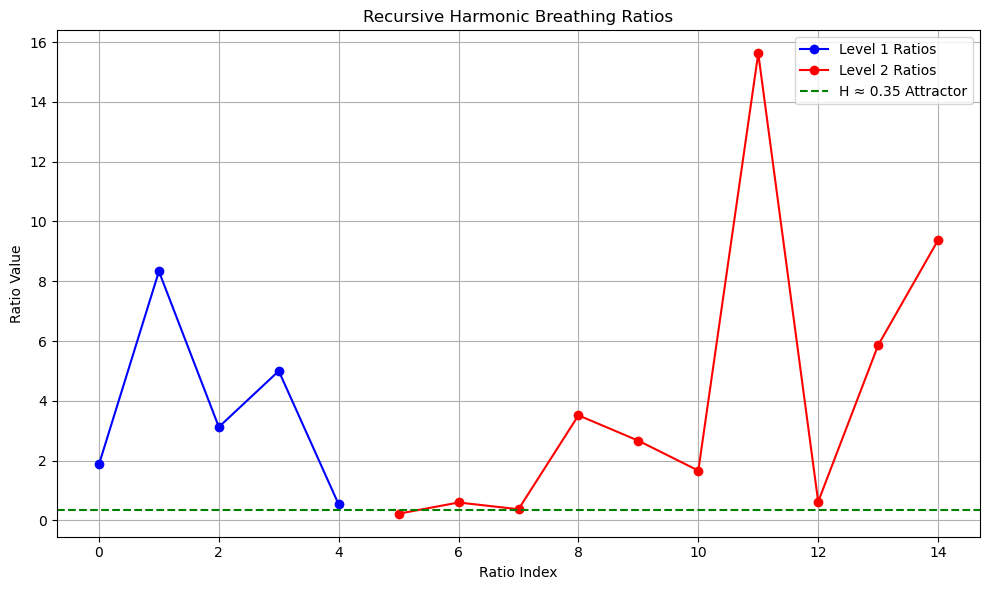

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Initial ratio pairs derived from the user's example
initial_ratios = {
    "Expansion (3 / 1.6)": 3 / 1.6,
    "Vertical Shock (5 / 0.6)": 5 / 0.6,
    "Horizontal Drive (5 / 1.6)": 5 / 1.6,
    "Collapse (3 / 0.6)": 3 / 0.6,
    "Subharmonic Fold (1.6 / 3)": 1.6 / 3
}

# Recursive step to compute second-level ratios (Level 2)
def compute_next_level(ratios):
    keys = list(ratios.keys())
    values = list(ratios.values())
    next_ratios = {}
    for i in range(len(values)):
        for j in range(i+1, len(values)):
            label = f"{keys[i]} / {keys[j]}"
            next_ratios[label] = values[i] / values[j]
    return next_ratios

# Compute level 2
level2_ratios = compute_next_level(initial_ratios)

# Filter and structure results for presentation
initial_df = pd.DataFrame(list(initial_ratios.items()), columns=["Interpretation", "Value"])
level2_df = pd.DataFrame(list(level2_ratios.items()), columns=["Level 2 Combination", "Value"])

# Plot values to visualize field structure
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(initial_ratios.values()), 'bo-', label='Level 1 Ratios')
ax.plot(list(range(len(initial_ratios), len(initial_ratios) + len(level2_ratios))),
        list(level2_ratios.values()), 'ro-', label='Level 2 Ratios')
ax.axhline(y=0.35, color='green', linestyle='--', label='H ≈ 0.35 Attractor')
ax.set_title('Recursive Harmonic Breathing Ratios')
ax.set_xlabel('Ratio Index')
ax.set_ylabel('Ratio Value')
ax.legend()
plt.grid(True)
plt.tight_layout()

tools.display_dataframe_to_user(name="Initial and Level 2 Harmonic Ratios", dataframe=pd.concat([initial_df, level2_df]))

plt.show()
